In [27]:
import polars as pl
from pathlib import Path

# Определяем базовую директорию (папка, где лежит скрипт)
# В Jupyter/IPython используйте Path.cwd(), в .py файлах можно Path(__file__).parent
base_dir = Path.cwd() 

# Указываем пути относительно корня проекта
data_path = base_dir / "data.csv"
events_path = base_dir / "events.csv"


In [28]:
import polars as pl

# Снимаем ограничения на количество выводимых столбцов и их ширину
pl.Config.set_tbl_cols(-1)       # -1 означает выводить все столбцы
pl.Config.set_tbl_width_chars(1000) # Увеличиваем ширину вывода в символах



# Ленивое чтение
users_scan = pl.scan_csv(data_path)
events_scan = pl.scan_csv(events_path)

# 1. Посмотрим на типы данных и названия всех колонок
print("--- Структура таблицы Пользователей ---")
print(users_scan.schema)

print("\n--- Структура таблицы Событий ---")
print(events_scan.schema)

# 2. Проверим пропуски (null values) в ключевых полях
null_stats = events_scan.select([
    pl.col("user_id").null_count().alias("null_users"),
    pl.col("session_id").null_count().alias("null_sessions"),
    pl.col("event_type").null_count().alias("null_events")
]).collect()

print("\n--- Пропущенные значения в событиях ---")
print(null_stats)

# 3. Уникальные значения event_type (что пользователи вообще делают?)
unique_events = events_scan.select("event_type").unique().collect()
print("\n--- Типы событий в системе ---")
print(unique_events)
# 4. Количество уникальных значений в каждом столбце
def get_unique_counts(lf: pl.LazyFrame, name: str):
    # Динамически выбираем все колонки и считаем n_unique для каждой
    unique_counts = lf.select([
        pl.all().n_unique()
    ]).collect()
    
    print(f"\n--- Уникальные значения в таблице {name} ---")
    print(unique_counts)

# Вызываем для обеих таблиц
get_unique_counts(users_scan, "Пользователей")
get_unique_counts(events_scan, "Событий")
# 5. Вывод уникальных значений, если их немного
def inspect_unique_values(lf: pl.LazyFrame, threshold: int = 10):
    # Сначала соберем схему, чтобы знать имена колонок
    columns = lf.collect_schema().names()
    
    for col in columns:
        # Считаем количество уникальных
        unique_vals_df = lf.select(pl.col(col).unique()).collect()
        count = unique_vals_df.height
        
        if count <= threshold:
            print(f"Столбец '{col}': {count} знач. -> {unique_vals_df[col].to_list()}")
        else:
            print(f"Столбец '{col}': {count} знач. (слишком много для вывода)")

print("\n--- Детальный осмотр уникальных значений ---")
inspect_unique_values(events_scan)
inspect_unique_values(users_scan)


--- Структура таблицы Пользователей ---
Schema([('order_id', Int64), ('user_id', Int64), ('status', String), ('gender', String), ('created_at', String), ('returned_at', String), ('shipped_at', String), ('delivered_at', String), ('num_of_item', Int64), ('product_id', Int64), ('inventory_item_id', Int64), ('sale_price', Float64), ('id', Int64), ('first_name', String), ('last_name', String), ('email', String), ('age', Int64), ('state', String), ('street_address', String), ('postal_code', String), ('city', String), ('country', String), ('traffic_source', String), ('user_geom', String), ('cost', Float64), ('category', String), ('brand', String), ('retail_price', Float64), ('department', String), ('sku', String), ('distribution_center_id', Int64), ('sold_at', String), ('product_category', String), ('product_name', String), ('product_brand', String), ('product_retail_price', Float64), ('product_department', String), ('product_sku', String), ('product_distribution_center_id', Int64), ('distrib

C:\Users\Fonon\AppData\Local\Temp\ipykernel_15228\3390753841.py:15: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(users_scan.schema)
C:\Users\Fonon\AppData\Local\Temp\ipykernel_15228\3390753841.py:18: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(events_scan.schema)



--- Пропущенные значения в событиях ---
shape: (1, 3)
┌────────────┬───────────────┬─────────────┐
│ null_users ┆ null_sessions ┆ null_events │
│ ---        ┆ ---           ┆ ---         │
│ u32        ┆ u32           ┆ u32         │
╞════════════╪═══════════════╪═════════════╡
│ 2248488    ┆ 0             ┆ 0           │
└────────────┴───────────────┴─────────────┘

--- Типы событий в системе ---
shape: (6, 1)
┌────────────┐
│ event_type │
│ ---        │
│ str        │
╞════════════╡
│ home       │
│ purchase   │
│ cart       │
│ department │
│ cancel     │
│ product    │
└────────────┘

--- Уникальные значения в таблице Пользователей ---
shape: (1, 49)
┌──────────┬─────────┬────────┬────────┬────────────┬─────────────┬────────────┬──────────────┬─────────────┬────────────┬───────────────────┬────────────┬───────┬────────────┬───────────┬───────┬─────┬───────┬────────────────┬─────────────┬──────┬─────────┬────────────────┬───────────┬───────┬──────────┬───────┬──────────────┬───────

In [29]:
# Смотрим первые 5 строк таблицы пользователей
print("--- Первые строки: ПОЛЬЗОВАТЕЛИ ---")
print(users_scan.head(5).collect())

# Смотрим первые 5 строк таблицы событий
print("--- Первые строки: СОБЫТИЯ ---")
print(events_scan.head(5).collect())

--- Первые строки: ПОЛЬЗОВАТЕЛИ ---
shape: (5, 49)
┌──────────┬─────────┬──────────┬────────┬───────────────────────────┬─────────────┬───────────────────────────┬────────────────────────┬─────────────┬────────────┬───────────────────┬────────────┬───────┬────────────┬─────────────┬───────────────────────────────┬─────┬───────────────┬────────────────────────────┬─────────────┬────────────┬───────────────┬────────────────┬──────────────────────────────────┬───────────┬───────────────────────────────┬────────────────────┬──────────────┬────────────┬──────────────────────────────────┬────────────────────────┬─────────┬───────────────────────────────┬──────────────────────────────────┬────────────────────┬──────────────────────┬────────────────────┬──────────────────────────────────┬──────────────────────────────────┬──────────────────────────┬───────────────┬────────────────────┬───────────────────┬─────────────────┬─────────────────────┬────────────────────┬──────────┬──────────────────

In [30]:
import polars as pl

# Устанавливаем количество строк, которые будут видны при принудительном выводе
pl.Config.set_tbl_rows(50) 

# Если колонок тоже много и они скрываются:
pl.Config.set_tbl_cols(50)


# Универсальный формат даты
datetime_format = "%Y-%m-%d %H:%M:%S%.f%z"

# 1. Обработка заказов с учетом возвратов
orders_processed = (
    users_scan
    .with_columns([
        pl.col("created_at").str.to_datetime(datetime_format),
        # Считаем маржу только если заказ не отменен и не возвращен
        # Если статус плохой, маржа = 0 (или можно просто отфильтровать)
        pl.when(pl.col("status").is_in(["Cancelled", "Returned"]))
        .then(0)
        .otherwise(pl.col("sale_price") - pl.col("cost"))
        .alias("margin")
    ])
    # Опционально: можно вообще исключить эти строки, чтобы не искажать среднее
    # .filter(~pl.col("status").is_in(["Cancelled", "Returned"]))
    .filter(pl.col("created_at").is_not_null())
    .sort("created_at")
)
# 2. Аналитика маржи
margin_analysis = (
    orders_processed
    .group_by_dynamic(
        "created_at", 
        every="1d", 
        group_by="traffic_source"
    )
    .agg([
        pl.len().alias("orders_count"),
        pl.col("margin").sum().alias("total_margin"),
        pl.col("margin").mean().alias("avg_margin_per_order")
    ])
    .collect()
)

# 3. Аналитика событий (кликов)
events_volume = (
    events_scan
    .with_columns(pl.col("created_at").str.to_datetime(datetime_format))
    .filter(pl.col("created_at").is_not_null())
    .sort("created_at")
    .group_by_dynamic("created_at", every="1d", group_by="traffic_source")
    .agg(pl.len().alias("clicks_count"))
    .collect()
)

# 4. Объединение для расчета конверсии и ROMI
# Соединяем по дате и источнику
final_stats = (
    margin_analysis.join(
        events_volume, 
        on=["created_at", "traffic_source"], 
        how="left"
    )
    .with_columns([
        (pl.col("orders_count") / pl.col("clicks_count")).alias("conversion_rate")
    ])
)

print(final_stats.sort("total_margin", descending=True).head(50))

shape: (50, 7)
┌────────────────┬─────────────────────────┬──────────────┬───────────────┬──────────────────────┬──────────────┬─────────────────┐
│ traffic_source ┆ created_at              ┆ orders_count ┆ total_margin  ┆ avg_margin_per_order ┆ clicks_count ┆ conversion_rate │
│ ---            ┆ ---                     ┆ ---          ┆ ---           ┆ ---                  ┆ ---          ┆ ---             │
│ str            ┆ datetime[μs, UTC]       ┆ u32          ┆ f64           ┆ f64                  ┆ u32          ┆ f64             │
╞════════════════╪═════════════════════════╪══════════════╪═══════════════╪══════════════════════╪══════════════╪═════════════════╡
│ Search         ┆ 2026-03-10 00:00:00 UTC ┆ 5694         ┆ 126837.368831 ┆ 22.275618            ┆ null         ┆ null            │
│ Search         ┆ 2026-03-09 00:00:00 UTC ┆ 3288         ┆ 76034.062403  ┆ 23.124715            ┆ null         ┆ null            │
│ Search         ┆ 2026-03-08 00:00:00 UTC ┆ 2409         ┆ 5

In [31]:
print(final_stats.select("traffic_source").unique())

shape: (5, 1)
┌────────────────┐
│ traffic_source │
│ ---            │
│ str            │
╞════════════════╡
│ Display        │
│ Facebook       │
│ Search         │
│ Email          │
│ Organic        │
└────────────────┘


In [32]:
# Группируем по источнику и берем топ-3 дня для каждого
top_per_source = (
    final_stats
    .sort(["traffic_source", "total_margin"], descending=[False, True])
    .group_by("traffic_source")
    .head(3)
)

print(top_per_source)

shape: (15, 7)
┌────────────────┬─────────────────────────┬──────────────┬───────────────┬──────────────────────┬──────────────┬─────────────────┐
│ traffic_source ┆ created_at              ┆ orders_count ┆ total_margin  ┆ avg_margin_per_order ┆ clicks_count ┆ conversion_rate │
│ ---            ┆ ---                     ┆ ---          ┆ ---           ┆ ---                  ┆ ---          ┆ ---             │
│ str            ┆ datetime[μs, UTC]       ┆ u32          ┆ f64           ┆ f64                  ┆ u32          ┆ f64             │
╞════════════════╪═════════════════════════╪══════════════╪═══════════════╪══════════════════════╪══════════════╪═════════════════╡
│ Display        ┆ 2026-03-10 00:00:00 UTC ┆ 276          ┆ 5291.854906   ┆ 19.173387            ┆ null         ┆ null            │
│ Display        ┆ 2026-03-09 00:00:00 UTC ┆ 168          ┆ 4482.928428   ┆ 26.684098            ┆ null         ┆ null            │
│ Display        ┆ 2026-03-07 00:00:00 UTC ┆ 111          ┆ 2

In [33]:
# Проверка названий в заказах
print("Источники в заказах:", orders_processed.select("traffic_source").unique().collect())

# Проверка названий в событиях
print("Источники в событиях:", events_scan.select("traffic_source").unique().collect())

Источники в заказах: shape: (5, 1)
┌────────────────┐
│ traffic_source │
│ ---            │
│ str            │
╞════════════════╡
│ Email          │
│ Search         │
│ Organic        │
│ Display        │
│ Facebook       │
└────────────────┘
Источники в событиях: shape: (5, 1)
┌────────────────┐
│ traffic_source │
│ ---            │
│ str            │
╞════════════════╡
│ Email          │
│ Adwords        │
│ YouTube        │
│ Facebook       │
│ Organic        │
└────────────────┘


In [34]:
# Агрегируем всё время в один отчет по каналам
summary_report = (
    final_stats
    .group_by("traffic_source")
    .agg([
        pl.col("orders_count").sum().alias("total_orders"),
        pl.col("total_margin").sum().alias("grand_total_margin"),
        pl.col("clicks_count").sum().alias("total_clicks"),
        # Средняя конверсия по каналу за весь период
        (pl.col("orders_count").sum() / pl.col("clicks_count").sum()).alias("avg_cr")
    ])
    .sort("grand_total_margin", descending=True)
)

print(summary_report)

shape: (5, 5)
┌────────────────┬──────────────┬────────────────────┬──────────────┬──────────┐
│ traffic_source ┆ total_orders ┆ grand_total_margin ┆ total_clicks ┆ avg_cr   │
│ ---            ┆ ---          ┆ ---                ┆ ---          ┆ ---      │
│ str            ┆ u32          ┆ f64                ┆ u32          ┆ f64      │
╞════════════════╪══════════════╪════════════════════╪══════════════╪══════════╡
│ Search         ┆ 382227       ┆ 8.8364e6           ┆ 0            ┆ inf      │
│ Organic        ┆ 82197        ┆ 1.9140e6           ┆ 225708       ┆ 0.364174 │
│ Facebook       ┆ 32283        ┆ 745436.51793       ┆ 405136       ┆ 0.079684 │
│ Email          ┆ 26598        ┆ 621832.92595       ┆ 1772260      ┆ 0.015008 │
│ Display        ┆ 22473        ┆ 516742.732541      ┆ 0            ┆ inf      │
└────────────────┴──────────────┴────────────────────┴──────────────┴──────────┘


In [35]:
import matplotlib.pyplot as plt

# Группируем по неделям ('1w')
weekly_margin = (
    orders_processed
    .group_by_dynamic(
        "created_at",
        every="1w",
        group_by="traffic_source"
    )
    .agg(pl.col("margin").sum().alias("total_margin"))
    .collect()
)

# Переводим в широкий формат (Pivot), чтобы было удобно строить графики
# Строки — даты, колонки — источники
pivot_margin = (
    weekly_margin
    .pivot(values="total_margin", index="created_at", on="traffic_source")
    .sort("created_at")
    .fill_null(0) # Если в какую-то неделю по источнику не было продаж
)

print(pivot_margin)

shape: (376, 6)
┌─────────────────────────┬──────────────┬───────────────┬──────────────┬──────────────┬──────────────┐
│ created_at              ┆ Email        ┆ Search        ┆ Display      ┆ Organic      ┆ Facebook     │
│ ---                     ┆ ---          ┆ ---           ┆ ---          ┆ ---          ┆ ---          │
│ datetime[μs, UTC]       ┆ f64          ┆ f64           ┆ f64          ┆ f64          ┆ f64          │
╞═════════════════════════╪══════════════╪═══════════════╪══════════════╪══════════════╪══════════════╡
│ 2018-12-31 00:00:00 UTC ┆ 0.0          ┆ 30.077459     ┆ 0.0          ┆ 0.0          ┆ 0.0          │
│ 2019-01-07 00:00:00 UTC ┆ 0.0          ┆ 230.059377    ┆ 0.0          ┆ 0.0          ┆ 0.0          │
│ 2019-01-14 00:00:00 UTC ┆ 60.464883    ┆ 619.740657    ┆ 0.0          ┆ 0.0          ┆ 0.0          │
│ 2019-01-21 00:00:00 UTC ┆ 171.934979   ┆ 15.87222      ┆ 0.0          ┆ 276.572335   ┆ 0.0          │
│ 2019-01-28 00:00:00 UTC ┆ 0.0          ┆ 1691.

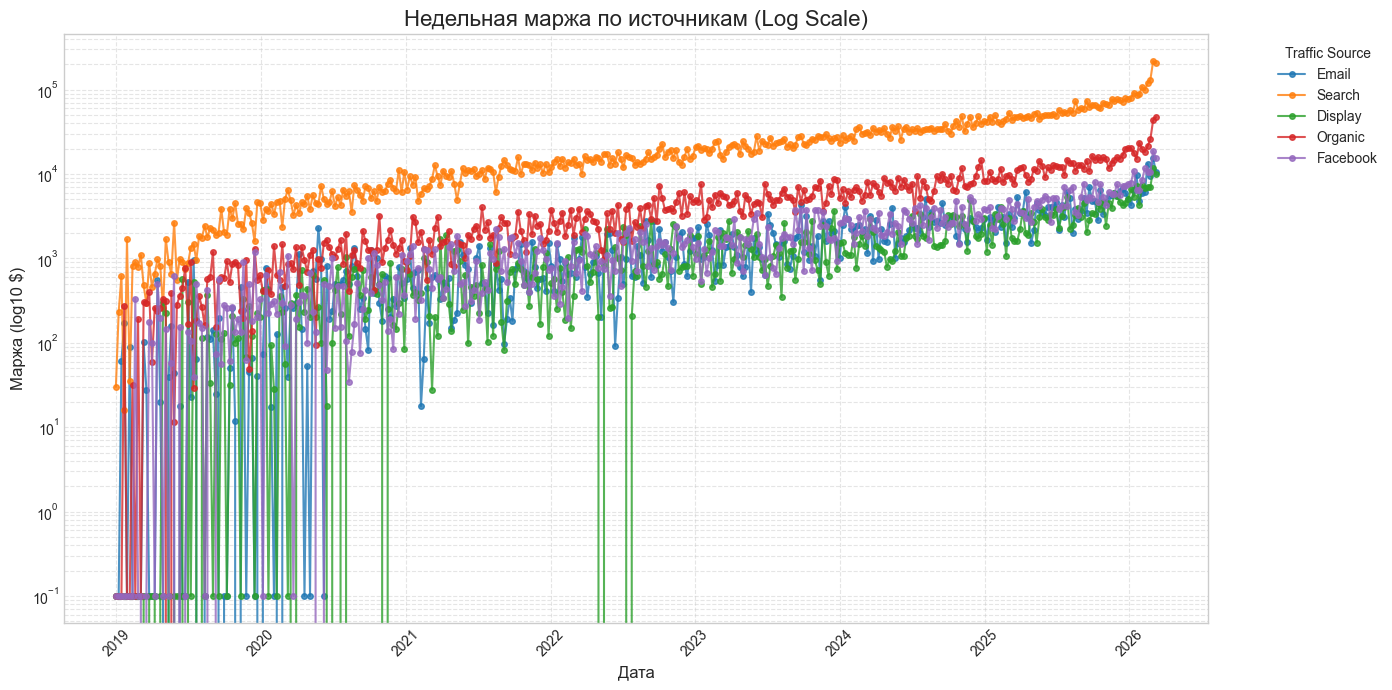

In [36]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Агрегируем данные по неделям
weekly_data = (
    orders_processed
    .group_by_dynamic(
        "created_at",
        every="1w",
        group_by="traffic_source"
    )
    .agg(pl.col("margin").sum().alias("total_margin"))
    .collect()
)

# 2. Разворачиваем таблицу (Pivot)
pivot_margin = (
    weekly_data
    .pivot(values="total_margin", index="created_at", on="traffic_source")
    .sort("created_at")
    .fill_null(0.1) # Заменяем 0 на 0.1, так как log(0) не определен
)

# 3. Визуализация
plt.figure(figsize=(14, 7))

for column in pivot_margin.columns:
    if column != "created_at":
        plt.plot(
            pivot_margin["created_at"], 
            pivot_margin[column], 
            marker='o', 
            markersize=4,
            label=column,
            alpha=0.8
        )

# Переключаем ось Y в логарифмический режим
plt.yscale('log')

# Настройка сетки и подписей
plt.title("Недельная маржа по источникам (Log Scale)", fontsize=16)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Маржа (log10 $)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5) # Сетка для обоих масштабов
plt.legend(title="Traffic Source", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [37]:
import polars as pl

# 1. Считаем браузеры, принудительно кастуя user_id в строку
user_browsers = (
    events_scan
    .with_columns(pl.col("user_id").cast(pl.Utf8)) # Кастуем в строку
    .group_by("user_id")
    .agg(pl.col("browser").mode().first())
    .collect()
)

# 2. Добавляем браузер в таблицу заказов, также кастуя user_id
orders_with_browser = (
    orders_processed
    .with_columns(pl.col("user_id").cast(pl.Utf8)) # Кастуем в строку
    .join(user_browsers.lazy(), on="user_id", how="left")
    .with_columns(pl.col("browser").fill_null("Unknown"))
)
# 3. Агрегируем по неделям
weekly_browser_margin = (
    orders_with_browser
    .sort("created_at") # КРИТИЧЕСКИ ВАЖНО: возвращаем хронологический порядок
    .group_by_dynamic(
        "created_at",
        every="1w",
        group_by=["traffic_source", "browser"]
    )
    .agg(pl.col("margin").sum().alias("total_margin"))
    .collect()
)

print(weekly_browser_margin.sort("total_margin", descending=True).head(10))

shape: (10, 4)
┌────────────────┬─────────┬─────────────────────────┬───────────────┐
│ traffic_source ┆ browser ┆ created_at              ┆ total_margin  │
│ ---            ┆ ---     ┆ ---                     ┆ ---           │
│ str            ┆ str     ┆ datetime[μs, UTC]       ┆ f64           │
╞════════════════╪═════════╪═════════════════════════╪═══════════════╡
│ Search         ┆ Chrome  ┆ 2026-03-02 00:00:00 UTC ┆ 124549.148844 │
│ Search         ┆ Chrome  ┆ 2026-03-09 00:00:00 UTC ┆ 119638.237824 │
│ Search         ┆ Chrome  ┆ 2026-02-23 00:00:00 UTC ┆ 75187.020499  │
│ Search         ┆ Chrome  ┆ 2026-02-16 00:00:00 UTC ┆ 68120.15329   │
│ Search         ┆ Chrome  ┆ 2026-02-09 00:00:00 UTC ┆ 63466.895504  │
│ Search         ┆ Chrome  ┆ 2026-02-02 00:00:00 UTC ┆ 62680.621163  │
│ Search         ┆ Chrome  ┆ 2026-01-12 00:00:00 UTC ┆ 54209.717424  │
│ Search         ┆ Chrome  ┆ 2026-01-19 00:00:00 UTC ┆ 52212.181118  │
│ Search         ┆ Chrome  ┆ 2026-01-05 00:00:00 UTC ┆ 52078.8

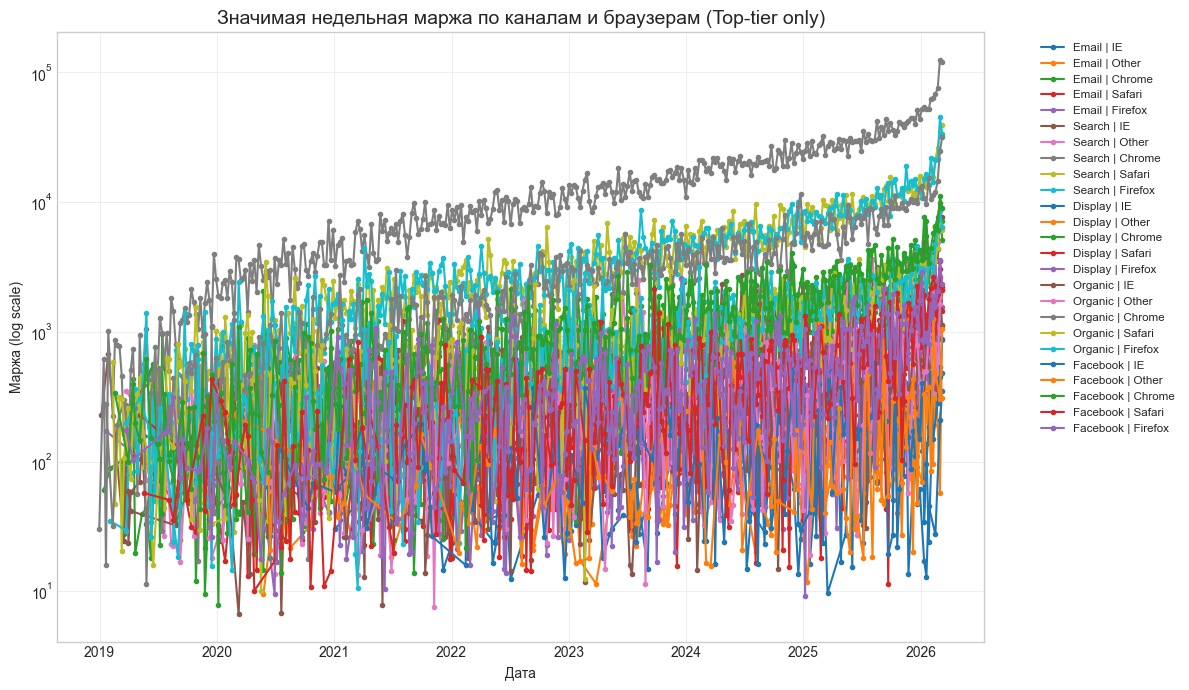

In [38]:
import matplotlib.pyplot as plt

# 1. Считаем общую маржу по каждой паре, чтобы найти лидеров
top_combinations = (
    weekly_browser_margin
    .group_by(["traffic_source", "browser"])
    .agg(pl.col("total_margin").sum().alias("grand_total"))
    .filter(pl.col("grand_total") > 5000) # Порог отсечения (можно менять)
    .select(["traffic_source", "browser"])
)

# 2. Фильтруем основные данные, оставляя только значимые пары
filtered_margin = weekly_browser_margin.join(
    top_combinations, 
    on=["traffic_source", "browser"], 
    how="inner"
)

# 3. Подготовка к графику
plot_df = (
    filtered_margin
    .with_columns((pl.col("traffic_source") + " | " + pl.col("browser")).alias("label"))
    .pivot(values="total_margin", index="created_at", on="label")
    .sort("created_at")
    # Теперь НЕ используем fill_null(0.1), чтобы пустые точки просто не соединялись
)

plt.figure(figsize=(12, 7))

for column in plot_df.columns:
    if column != "created_at":
        # Убираем значения <= 0, чтобы логарифм не выдал ошибку
        mask = plot_df[column] > 0
        if mask.any():
            plt.plot(
                plot_df["created_at"].filter(mask), 
                plot_df[column].filter(mask), 
                label=column, 
                marker='.', 
                linewidth=1.5
            )

plt.yscale('log')
plt.title("Значимая недельная маржа по каналам и браузерам (Top-tier only)", fontsize=14)
plt.ylabel("Маржа (log scale)")
plt.xlabel("Дата")
plt.grid(True, which="major", ls="-", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

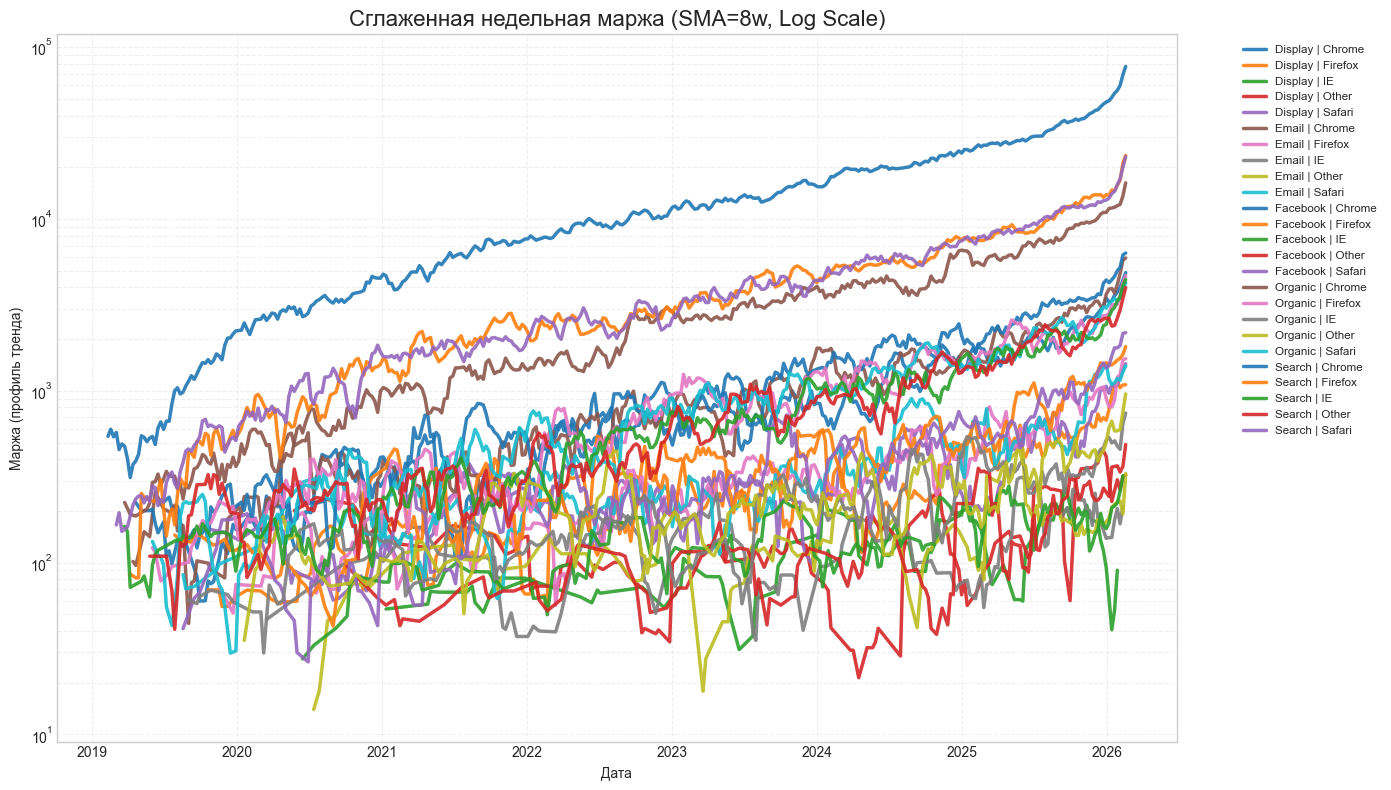

In [39]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Параметры сглаживания
WINDOW_SIZE = 8 # Окно в 4 недели (примерно месяц)

# 2. Применяем скользящее среднее внутри каждой группы (Источник + Браузер)
smoothed_data = (
    weekly_browser_margin
    .sort(["traffic_source", "browser", "created_at"])
    .with_columns(
        pl.col("total_margin")
        .rolling_mean(window_size=WINDOW_SIZE, center=True)
        .over(["traffic_source", "browser"])
        .alias("smoothed_margin")
    )
    .filter(pl.col("smoothed_margin").is_not_null()) # Убираем края, где не хватило данных для окна
)

# 3. Фильтр по объему (оставляем только значимых)
top_labels = (
    smoothed_data
    .group_by(["traffic_source", "browser"])
    .agg(pl.col("total_margin").sum().alias("grand_total"))
    .filter(pl.col("grand_total") > 10000) # Порог для "высшей лиги"
    .select(["traffic_source", "browser"])
)

final_plot_df = (
    smoothed_data
    .join(top_labels, on=["traffic_source", "browser"], how="inner")
    .with_columns((pl.col("traffic_source") + " | " + pl.col("browser")).alias("label"))
    .pivot(values="smoothed_margin", index="created_at", on="label")
    .sort("created_at")
)

# 4. Визуализация
plt.figure(figsize=(14, 8))

for column in final_plot_df.columns:
    if column != "created_at":
        # Убираем нулевые значения для логарифмической шкалы
        mask = final_plot_df[column] > 1e-1 
        if mask.any():
            plt.plot(
                final_plot_df["created_at"].filter(mask), 
                final_plot_df[column].filter(mask), 
                label=column, 
                linewidth=2.5, # Делаем линии толще и мягче
                alpha=0.9
            )

plt.yscale('log')
plt.title(f"Сглаженная недельная маржа (SMA={WINDOW_SIZE}w, Log Scale)", fontsize=16)
plt.ylabel("Маржа (профиль тренда)")
plt.xlabel("Дата")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

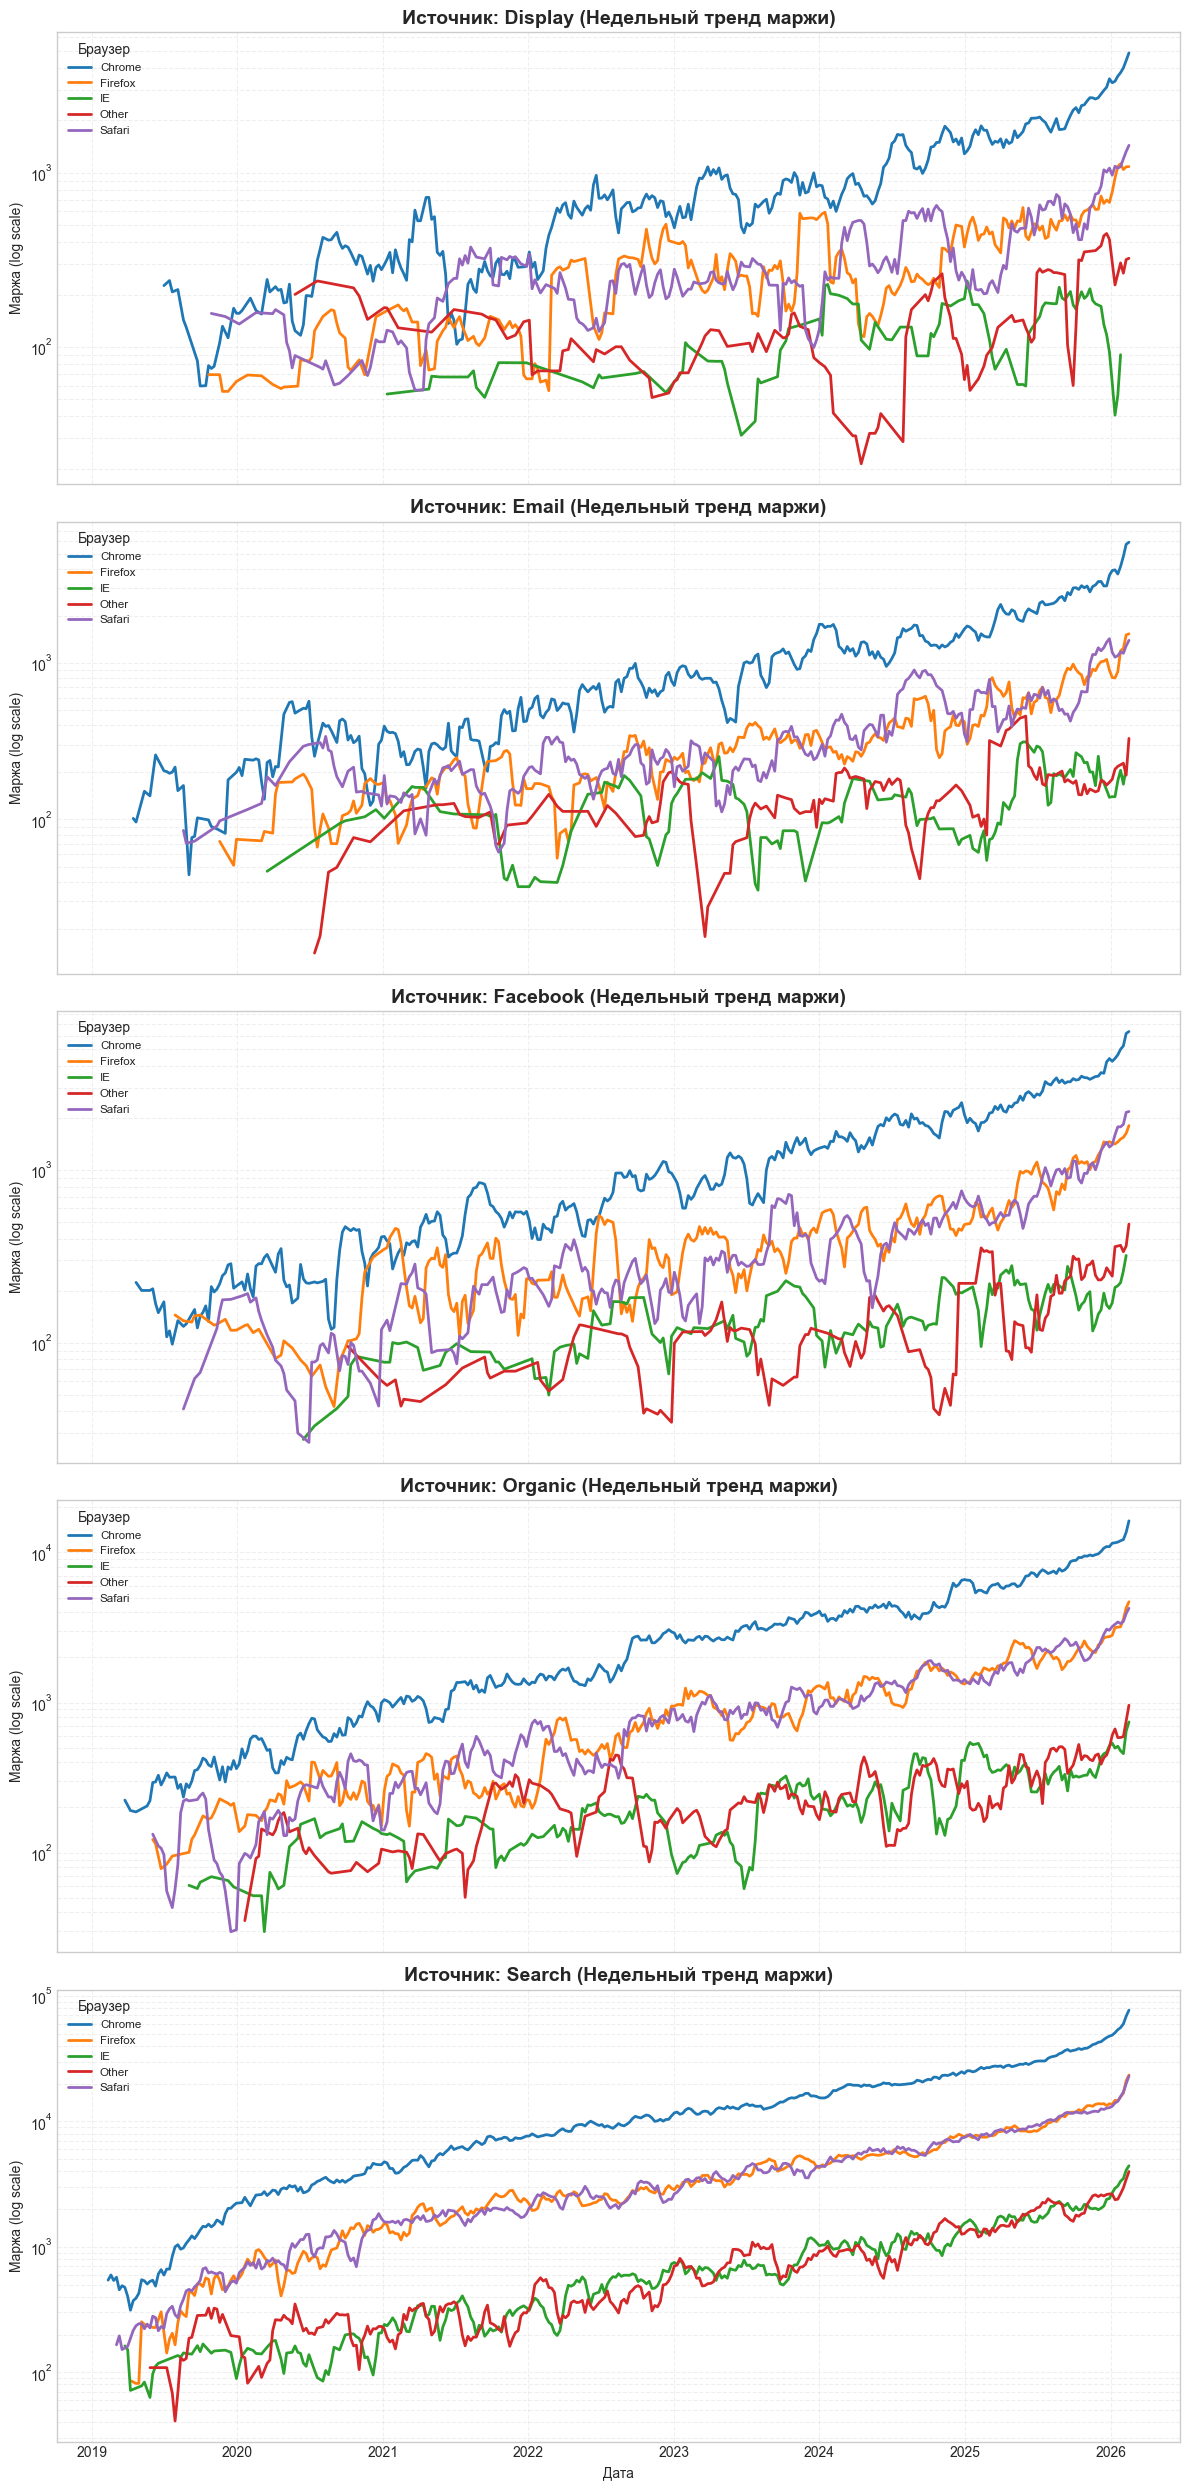

Данные для детальных графиков сохранены: c:\Users\Fonon\Desktop\Хактатон_2026 МФТИ\margin_by_source_and_browser.csv


In [ ]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Берем наши сглаженные данные (из предыдущего шага)
# Убедитесь, что weekly_browser_margin и smoothed_data рассчитаны
sources = smoothed_data.select("traffic_source").unique().to_series().to_list()
num_sources = len(sources)

# 2. Создаем сетку графиков (один столбец, много строк)
fig, axes = plt.subplots(num_sources, 1, figsize=(12, 5 * num_sources), sharex=True)

# Если источник всего один, axes не будет списком, превращаем в список для цикла
if num_sources == 1:
    axes = [axes]

for i, source in enumerate(sources):
    ax = axes[i]
    
    # Фильтруем данные только для текущего источника
    source_data = (
        smoothed_data
        .filter(pl.col("traffic_source") == source)
        .pivot(values="smoothed_margin", index="created_at", on="browser")
        .sort("created_at")
    )
    
    # Строим линии для каждого браузера внутри этого источника
    for browser in source_data.columns:
        if browser != "created_at":
            mask = source_data[browser] > 0.1
            if mask.any():
                ax.plot(
                    source_data["created_at"].filter(mask), 
                    source_data[browser].filter(mask), 
                    label=browser, 
                    linewidth=2
                )
    
    # Настройки для конкретного подобъекта (источника)
    ax.set_yscale('log')
    ax.set_title(f"Источник: {source} (Недельный тренд маржи)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Маржа (log scale)")
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(title="Браузер", loc='upper left', fontsize='small')

# Общие настройки
plt.xlabel("Дата")
plt.tight_layout()
plt.show()






# # 1. Подготовка "широкого" формата для сохранения
# export_pivot = (
#     smoothed_data
#     .with_columns(
#         (pl.col("traffic_source") + " | " + pl.col("browser")).alias("source_browser")
#     )
#     .pivot(
#         values="smoothed_margin", 
#         index="created_at", 
#         on="source_browser"
#     )
#     .sort("created_at")
# )

# # 2. Сохраняем
# output_pivot_path = base_dir / "margin_by_source_and_browser.csv"
# export_pivot.write_csv(output_pivot_path)

# print(f"Данные для детальных графиков сохранены: {output_pivot_path}")

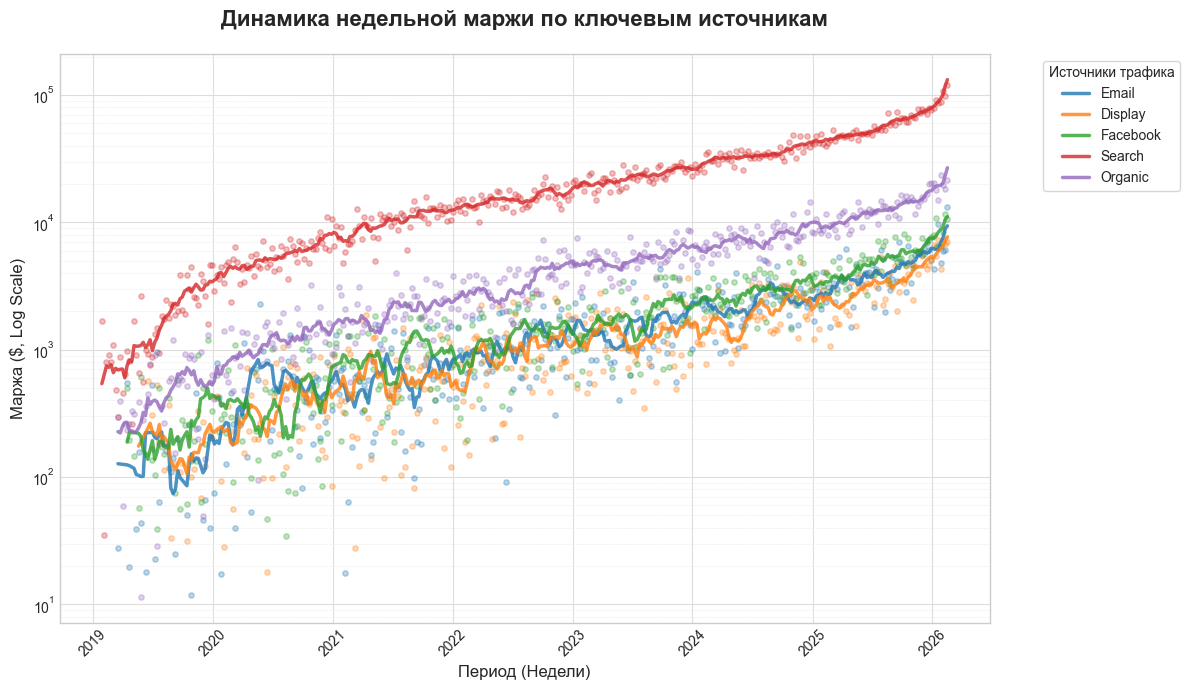

Файл успешно сохранен: c:\Users\Fonon\Desktop\Хактатон_2026 МФТИ\weekly_margin_analytics.csv
Размер сохраненной таблицы: (1805, 4)


In [ ]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Подготовка данных со сглаживанием (SMA-3 для подавления шума)
# Оставляем только те источники, у которых суммарная маржа значима
top_sources = (
    weekly_data
    .group_by("traffic_source")
    .agg(pl.col("total_margin").sum())
    .filter(pl.col("total_margin") > 10000)
    .select("traffic_source")
)

plot_data = (
    weekly_data
    .join(top_sources, on="traffic_source", how="inner")
    .sort(["traffic_source", "created_at"])
    .with_columns(
        pl.col("total_margin")
        .rolling_mean(window_size=8, center=True)
        .over("traffic_source")
        .alias("smoothed_margin")
    )
)

# 2. Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid') # Опрятный светлый стиль
fig, ax = plt.subplots(figsize=(12, 7))

# Цветовая палитра (Colorblind-friendly)
colors = plt.cm.tab10.colors 

for i, source in enumerate(plot_data["traffic_source"].unique()):
    subset = plot_data.filter(pl.col("traffic_source") == source)
    
    # Рисуем только положительные значения (для корректного логарифма)
    valid_mask = subset["smoothed_margin"] > 0
    x = subset["created_at"].filter(valid_mask)
    y = subset["smoothed_margin"].filter(valid_mask)
    
    line, = ax.plot(x, y, label=source, linewidth=2.5, alpha=0.8, color=colors[i % 10])
    
    # Добавляем полупрозрачные точки реальных данных на фоне
    raw_y = subset["total_margin"].filter(valid_mask)
    ax.scatter(x, raw_y, color=line.get_color(), s=15, alpha=0.3)

# 3. Тонкая настройка осей и сетки
ax.set_yscale('log')
ax.set_title("Динамика недельной маржи по ключевым источникам", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Период (Недели)", fontsize=12)
ax.set_ylabel("Маржа ($, Log Scale)", fontsize=12)

# Сетка для основных и промежуточных порядков (важно для логарифмов)
ax.grid(True, which="major", color="#DDDDDD", linewidth=0.8)
ax.grid(True, which="minor", color="#EEEEEE", linestyle="--", linewidth=0.5)

# Легенда за пределами графика
ax.legend(title="Источники трафика", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# # Определяем путь для сохранения (в ту же папку, где лежит скрипт)
# output_path = base_dir / "weekly_margin_analytics.csv"

# # Сохраняем результат
# # .collect() не нужен, так как plot_data у нас уже материализован (Eager)
# plot_data.write_csv(output_path)

# print(f"Файл успешно сохранен: {output_path}")
# print(f"Размер сохраненной таблицы: {plot_data.shape}")

In [44]:
# Смотрим все уникальные статусы
print(orders_processed.select("status").unique().collect())

shape: (5, 1)
┌────────────┐
│ status     │
│ ---        │
│ str        │
╞════════════╡
│ Shipped    │
│ Complete   │
│ Returned   │
│ Processing │
│ Cancelled  │
└────────────┘
